# Notebook 01: Generating the SAR ADC Dataset

---

This notebook walks through **NeuroSAR's data pipeline** — from random design-parameter sampling to physically-plausible waveform generation — and visualises the resulting dataset. Understanding the dataset is essential before training the PINN.

## Learning objectives

- Understand what a NeuroSAR training sample represents (one SAR conversion event).
- Generate a synthetic dataset using Mode A (analytical physics models).
- Visualise DAC trial voltages, differential settling waveforms, and comparator regeneration.
- Understand Mode A vs Mode B data sources.
- Inspect dataset statistics: parameter distributions, energy histograms, metastability profiles.

---

## 0. Environment Setup

All NeuroSAR source modules live in `../src/`. We insert the project root into `sys.path` so that `from src.xxx import yyy` works correctly from any notebook.

In [2]:
import sys
import os

# Make sure the project root is on the path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/ayanbiswas/Documents/Development/NeuroSAR


In [3]:
import numpy as np
import torch
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NeuroSAR modules
from src.config import DESIGN, TRAIN, DATA_PROC
from src.dataset import (
    generate_synthetic_dataset,
    save_dataset,
    load_dataset,
    build_dataloaders,
    DESIGN_PARAM_NAMES,
    SARDataset,
)
from src.plotting import (
    plot_dac_waveform,
    plot_comparator_regen,
    plot_differential_waveform,
    plot_conversion_summary,
)
from src.utils import seed_everything

seed_everything(TRAIN.seed)
print(f"PyTorch version: {torch.__version__}")
print(f"Design space: {DESIGN.n_bits}-bit, {DESIGN.n_time_steps} time steps per bit cycle")

PyTorch version: 2.11.0
Design space: 10-bit, 64 time steps per bit cycle


---

## 1. What Is One Training Sample?

Each sample in the NeuroSAR dataset represents a **complete SAR conversion cycle** for one randomly drawn design point. It contains:

| Tensor | Shape | Description |
|---|---|---|
| `params` | `(9,)` | Design parameter vector $[V_{in}, V_{ref}, C_u, C_{load}, g_m, \tau, V_{os}, T, f_s]$ |
| `t_local` | `(T,)` | Normalised time axis $[0, 1)$ within each bit window |
| `vdac` | `(N+1,)` | DAC node voltage after each trial (index 0 = sampled value) |
| `vdiff` | `(N, T)` | Differential voltage waveform per bit cycle |
| `vcomp` | `(N, T)` | Comparator regeneration waveform per bit cycle |
| `energy` | `()` | Total conversion energy $E_{conv}$ (J) |
| `meta_dwell` | `(N,)` | Metastability dwell time per bit cycle (s) |
| `bits` | `(N,)` | Binary decision per bit cycle $\in \{0, 1\}$ |

With $N = 10$ bits and $T = 64$ time steps, each sample encodes $10 \times 64 = 640$ waveform points alongside scalar design parameters and FoM labels.

---

## 2. Mode A: Generating a Synthetic Dataset

Mode A uses the analytical physics models in `src/physics.py` to generate waveforms without any SPICE calls. The generator:

1. Samples $N_{samples}$ random design vectors uniformly from the design space.
2. Runs the ideal SAR binary search to determine bit decisions.
3. Computes `vdac` via charge redistribution.
4. Computes `vdiff` via exponential settling.
5. Computes `vcomp` via the comparator regeneration ODE.
6. Computes `energy` and `meta_dwell` from the analytical energy and metastability models.

Total generation time for 8,000 samples: ~5–10 seconds on CPU.

In [4]:
# Generate the synthetic dataset
# Adjust n_samples if you want a smaller/larger dataset for experimentation
N_SAMPLES = 2000  # Use 8000 for full training; 2000 here for quick demo

print(f"Generating {N_SAMPLES} synthetic SAR conversion samples...")
data = generate_synthetic_dataset(
    n_samples=N_SAMPLES,
    n_bits=DESIGN.n_bits,
    n_time=DESIGN.n_time_steps,
    seed=TRAIN.seed,
)

print("\nDataset tensors:")
for k, v in data.items():
    shape_str = str(tuple(v.shape)) if isinstance(v, torch.Tensor) else "scalar"
    print(f"  {k:15s}: {shape_str}")

Generating 2000 synthetic SAR conversion samples...

Dataset tensors:
  params         : (2000, 9)
  t_local        : (64,)
  vdac           : (2000, 11)
  vdiff          : (2000, 10, 64)
  vcomp          : (2000, 10, 64)
  energy         : (2000,)
  meta_dwell     : (2000, 10)
  bits           : (2000, 10)


In [5]:
# Save the dataset to disk for reuse in later notebooks
dataset_path = save_dataset(data)
print(f"\nDataset saved to: {dataset_path}")

[NeuroSAR] Dataset saved → /Users/ayanbiswas/Documents/Development/NeuroSAR/data/processed/sar_dataset.pt  (2000 samples)

Dataset saved to: /Users/ayanbiswas/Documents/Development/NeuroSAR/data/processed/sar_dataset.pt


---

## 3. Visualising Sample Waveforms

### 3.1 Single Conversion Cycle

Let's inspect one sample in detail — the DAC staircase, differential settling, and comparator regeneration across all 10 bit cycles.

In [6]:
# Pick a sample index to visualise
SAMPLE_IDX = 42

vdac  = data['vdac'][SAMPLE_IDX].numpy()    # (N_bits+1,)
vdiff = data['vdiff'][SAMPLE_IDX].numpy()   # (N_bits, T)
vcomp = data['vcomp'][SAMPLE_IDX].numpy()   # (N_bits, T)
t_local = data['t_local'].numpy()           # (T,)
params_s = data['params'][SAMPLE_IDX].numpy()
bits_s   = data['bits'][SAMPLE_IDX].numpy()
energy_s = data['energy'][SAMPLE_IDX].item()

print("Sample design parameters:")
for name, val in zip(DESIGN_PARAM_NAMES, params_s):
    print(f"  {name:12s} = {val:.4e}")
print(f"\nBit decisions:  {''.join(str(int(b)) for b in bits_s)}")
print(f"Energy:         {energy_s:.4e} J")
print(f"Max meta-dwell: {data['meta_dwell'][SAMPLE_IDX].max().item():.4e} s")

Sample design parameters:
  vin          = 1.2605e+00
  vref         = 1.8000e+00
  cu           = 3.1985e-14
  cload        = 7.6288e-14
  gm           = 1.5695e-03
  tau_regen    = 4.2173e-10
  vos          = 2.4754e-03
  temp         = 3.8843e+02
  fs           = 1.4491e+08

Bit decisions:  1000000000
Energy:         1.0739e-10 J
Max meta-dwell: 0.0000e+00 s


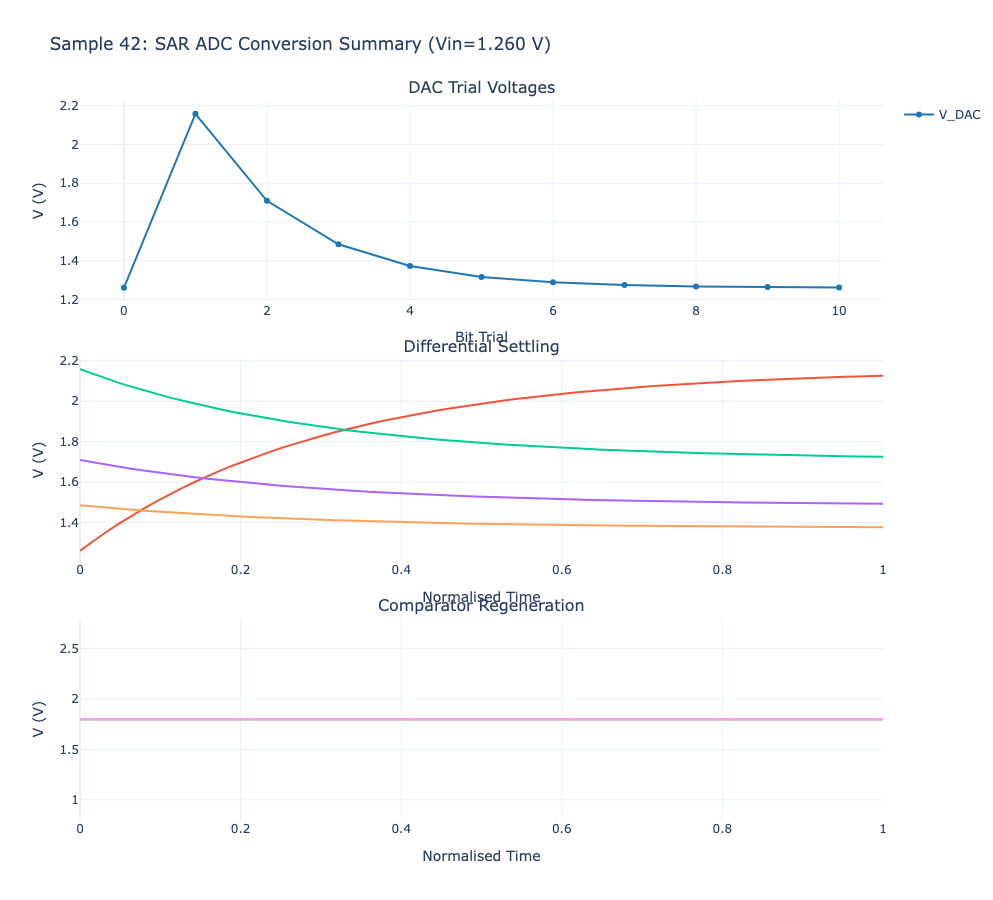

In [7]:
# Three-panel conversion summary plot
fig = plot_conversion_summary(
    vdac=vdac,
    vdiff=vdiff,
    vcomp=vcomp,
    t_local=t_local,
    title=f"Sample {SAMPLE_IDX}: SAR ADC Conversion Summary (Vin={params_s[0]:.3f} V)",
)
fig.show()

**Reading the plot:**

- **Top panel (DAC Trial Voltages):** The staircase shows the binary search converging from $V_{ref}/2$ toward $V_{in}$. MSB trials produce large steps; LSB trials produce fine adjustments.
- **Middle panel (Differential Settling):** Each curve shows the DAC node settling exponentially after a switching event. Earlier bits (larger steps) have coarser settling; later bits show fine residue.
- **Bottom panel (Comparator Regeneration):** The exponential growth from near-zero toward ±$V_{DD}$ represents the latch regenerating. Bits with small residues (near-metastable) show slow initial growth.

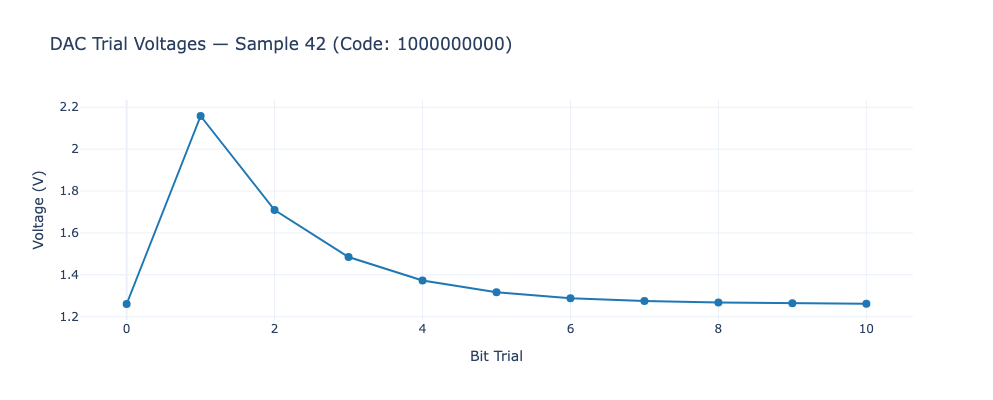

In [8]:
# DAC staircase only
fig_dac = plot_dac_waveform(
    vdac=vdac,
    n_bits=DESIGN.n_bits,
    title=f"DAC Trial Voltages — Sample {SAMPLE_IDX} (Code: {''.join(str(int(b)) for b in bits_s)})",
)
fig_dac.show()

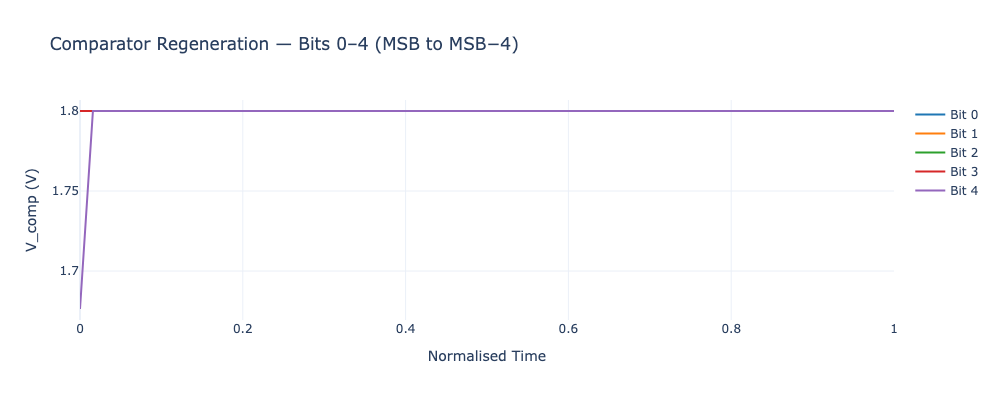

In [9]:
# Comparator regeneration for first 5 bits
fig_comp = plot_comparator_regen(
    vcomp=vcomp,
    t_local=t_local,
    bit_indices=list(range(5)),
    title="Comparator Regeneration — Bits 0–4 (MSB to MSB−4)",
)
fig_comp.show()

### 3.2 Comparing Multiple Samples

Below we overlay the comparator waveforms for 5 different samples to show the diversity in the dataset — different $g_m$, $\tau$, and $V_{residue}$ values produce dramatically different regeneration speeds.

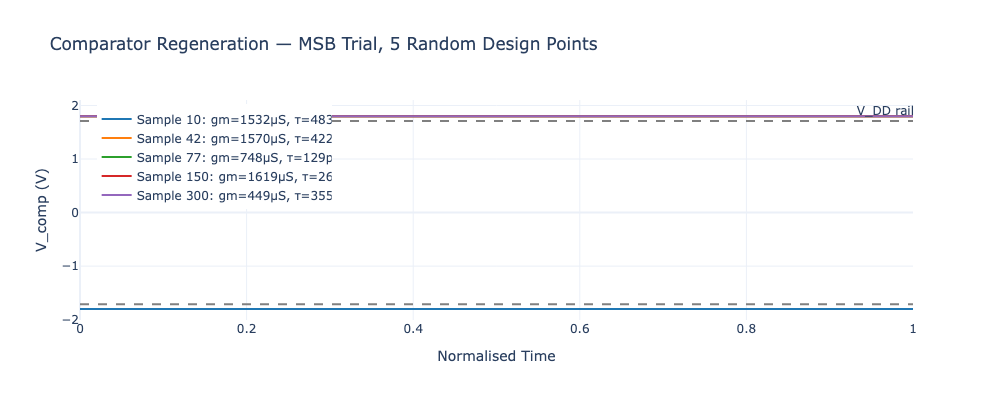

In [10]:
fig_overlay = go.Figure()
COLORS_LIST = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, idx in enumerate([10, 42, 77, 150, 300]):
    vcomp_i = data['vcomp'][idx, 0].numpy()  # MSB comparator waveform
    gm_i    = data['params'][idx, 4].item()
    tau_i   = data['params'][idx, 5].item()
    
    fig_overlay.add_trace(go.Scatter(
        x=t_local, y=vcomp_i,
        mode='lines',
        name=f'Sample {idx}: gm={gm_i*1e6:.0f}µS, τ={tau_i*1e12:.0f}ps',
        line=dict(color=COLORS_LIST[i], width=2),
    ))

fig_overlay.add_hline(y=1.8*0.95, line_dash='dash', line_color='gray',
                       annotation_text='V_DD rail')
fig_overlay.add_hline(y=-1.8*0.95, line_dash='dash', line_color='gray')

fig_overlay.update_layout(
    title='Comparator Regeneration — MSB Trial, 5 Random Design Points',
    xaxis_title='Normalised Time',
    yaxis_title='V_comp (V)',
    template='plotly_white',
    width=750, height=400,
    legend=dict(x=0.02, y=0.98),
)
fig_overlay.show()

---

## 4. Dataset Statistics

### 4.1 Design Parameter Distributions

All 9 parameters are sampled uniformly within their respective ranges, ensuring dense coverage of the design space.

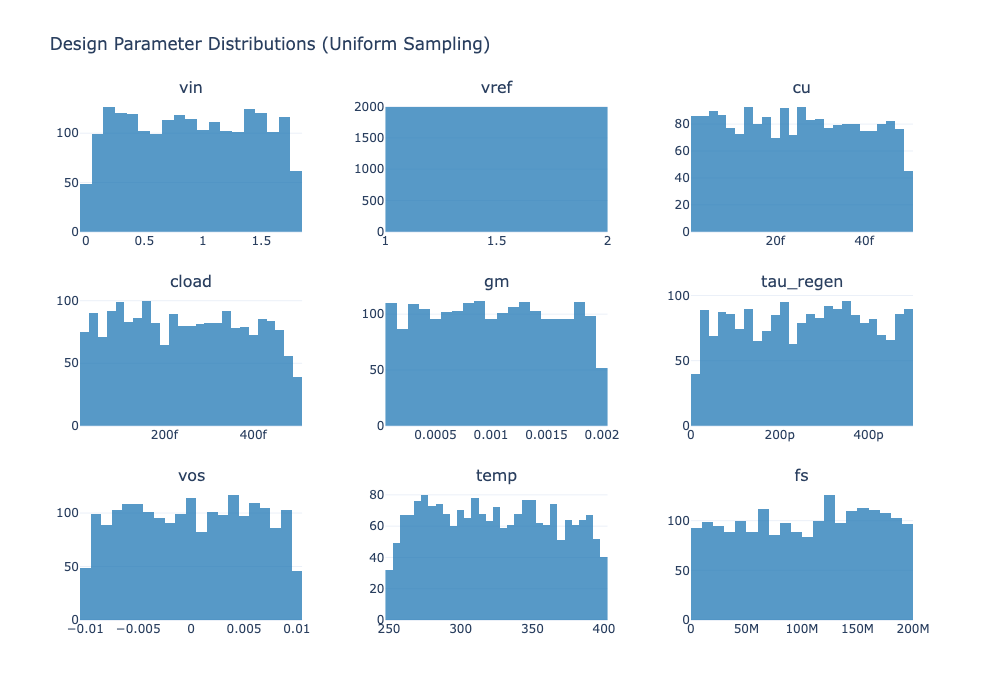

In [11]:
params_np = data['params'].numpy()  # (N, 9)

fig_params = make_subplots(
    rows=3, cols=3,
    subplot_titles=DESIGN_PARAM_NAMES,
    vertical_spacing=0.12,
    horizontal_spacing=0.1,
)

for i, name in enumerate(DESIGN_PARAM_NAMES):
    row = i // 3 + 1
    col = i % 3 + 1
    fig_params.add_trace(
        go.Histogram(
            x=params_np[:, i],
            nbinsx=30,
            name=name,
            showlegend=False,
            marker_color='#1f77b4',
            opacity=0.75,
        ),
        row=row, col=col,
    )

fig_params.update_layout(
    title='Design Parameter Distributions (Uniform Sampling)',
    template='plotly_white',
    height=700, width=900,
)
fig_params.show()

In [12]:
# Summary statistics for design parameters
import pandas as pd

stats_df = pd.DataFrame(params_np, columns=DESIGN_PARAM_NAMES).describe().T
stats_df = stats_df[['min', '25%', '50%', '75%', 'max', 'mean', 'std']]
print("Design Parameter Summary Statistics:")
print(stats_df.to_string(float_format='{:.3e}'.format))

Design Parameter Summary Statistics:
                 min        25%       50%       75%       max      mean       std
vin        9.337e-04  4.393e-01 8.928e-01 1.370e+00 1.799e+00 9.051e-01 5.228e-01
vref       1.800e+00  1.800e+00 1.800e+00 1.800e+00 1.800e+00 1.800e+00 0.000e+00
cu         1.031e-15  1.305e-14 2.526e-14 3.754e-14 4.999e-14 2.517e-14 1.420e-14
cload      1.015e-14  1.283e-13 2.468e-13 3.683e-13 4.999e-13 2.492e-13 1.394e-13
gm         5.081e-05  5.455e-04 1.028e-03 1.496e-03 2.000e-03 1.023e-03 5.625e-04
tau_regen  1.028e-11  1.324e-10 2.613e-10 3.744e-10 4.995e-10 2.561e-10 1.410e-10
vos       -1.000e-02 -5.051e-03 6.951e-05 4.991e-03 9.989e-03 1.811e-05 5.750e-03
temp       2.500e+02  2.865e+02 3.235e+02 3.603e+02 4.000e+02 3.240e+02 4.274e+01
fs         1.129e+06  5.339e+07 1.065e+08 1.531e+08 1.999e+08 1.026e+08 5.773e+07


### 4.2 Energy Distribution

Conversion energy spans several orders of magnitude across the design space. Large $C_u$ and high $g_m$ drive energy up; designs with small caps and efficient comparators can achieve sub-fJ conversion energy.

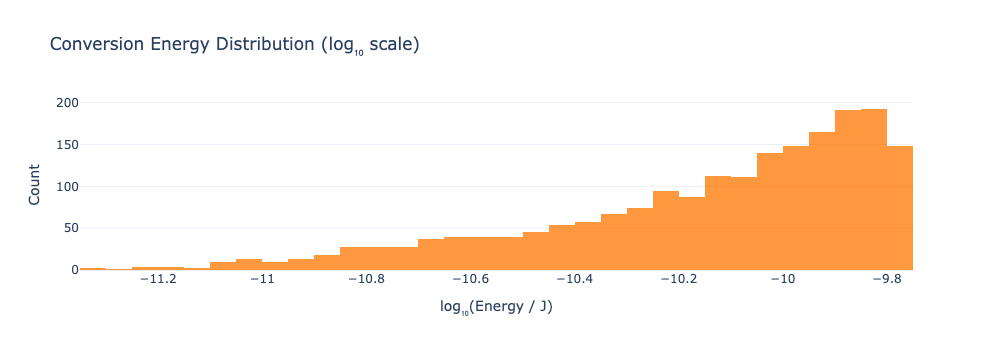

Energy statistics:
  Min:    4.541e-12 J
  Median: 8.784e-11 J
  Mean:   8.791e-11 J
  Max:    1.733e-10 J
  Range:  38.2× span


In [13]:
energy_np = data['energy'].numpy()  # (N,)

fig_energy = go.Figure()
fig_energy.add_trace(go.Histogram(
    x=np.log10(energy_np + 1e-30),
    nbinsx=40,
    name='log10(Energy)',
    marker_color='#ff7f0e',
    opacity=0.8,
))
fig_energy.update_layout(
    title='Conversion Energy Distribution (log₁₀ scale)',
    xaxis_title='log₁₀(Energy / J)',
    yaxis_title='Count',
    template='plotly_white',
    width=650, height=350,
)
fig_energy.show()

print(f"Energy statistics:")
print(f"  Min:    {energy_np.min():.3e} J")
print(f"  Median: {np.median(energy_np):.3e} J")
print(f"  Mean:   {energy_np.mean():.3e} J")
print(f"  Max:    {energy_np.max():.3e} J")
print(f"  Range:  {energy_np.max()/energy_np.min():.1f}× span")

### 4.3 Metastability Dwell Time Distribution

The metastability dwell time quantifies how close each bit decision comes to the metastability boundary. High dwell times signal dangerous design points.

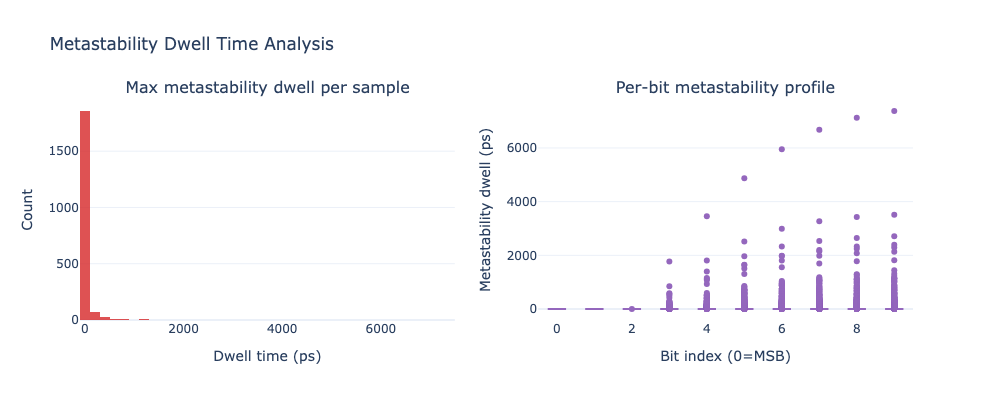


Metastability statistics (max dwell per sample):
  Min:    0.00 ps
  Median: 0.00 ps
  Max:    7376.51 ps


In [14]:
meta_np = data['meta_dwell'].numpy()  # (N, N_bits)
meta_max = meta_np.max(axis=1)        # Worst bit per sample

fig_meta = make_subplots(rows=1, cols=2,
    subplot_titles=['Max metastability dwell per sample', 'Per-bit metastability profile'])

fig_meta.add_trace(go.Histogram(
    x=meta_max * 1e12,  # convert to ps
    nbinsx=40,
    name='Max dwell',
    marker_color='#d62728',
    opacity=0.8,
), row=1, col=1)

fig_meta.add_trace(go.Box(
    y=(meta_np * 1e12).flatten(),
    x=np.tile(np.arange(DESIGN.n_bits), len(meta_np)),
    name='Per-bit dwell',
    marker_color='#9467bd',
), row=1, col=2)

fig_meta.update_xaxes(title_text='Dwell time (ps)', row=1, col=1)
fig_meta.update_xaxes(title_text='Bit index (0=MSB)', row=1, col=2)
fig_meta.update_yaxes(title_text='Count', row=1, col=1)
fig_meta.update_yaxes(title_text='Metastability dwell (ps)', row=1, col=2)

fig_meta.update_layout(
    title='Metastability Dwell Time Analysis',
    template='plotly_white',
    height=400, width=900,
    showlegend=False,
)
fig_meta.show()

print(f"\nMetastability statistics (max dwell per sample):")
print(f"  Min:    {meta_max.min()*1e12:.2f} ps")
print(f"  Median: {np.median(meta_max)*1e12:.2f} ps")
print(f"  Max:    {meta_max.max()*1e12:.2f} ps")

**Observation:** LSB trials (high bit indices, near $k=9$) tend to have larger metastability dwell times than MSB trials. This makes physical sense: at LSB resolution, $V_{residue}$ is on the order of $\frac{V_{ref}}{2^{10}} \approx 1.76$ mV — tiny residues that are slow to regenerate.

---

## 5. Building DataLoaders

The `build_dataloaders` function wraps the dataset in a PyTorch `DataLoader` with a 85/15 train/validation split and returns normalisation statistics.

In [15]:
train_dl, val_dl, norm_stats = build_dataloaders(
    data,
    val_fraction=TRAIN.val_fraction,
    batch_size=TRAIN.batch_size,
    seed=TRAIN.seed,
)

n_train = len(train_dl.dataset)
n_val   = len(val_dl.dataset)
print(f"Training samples:   {n_train}")
print(f"Validation samples: {n_val}")
print(f"Batch size:         {TRAIN.batch_size}")
print(f"Train batches/epoch:{len(train_dl)}")
print(f"Val   batches/epoch:{len(val_dl)}")

print("\nNormalisation ranges (input parameters):")
for name in DESIGN_PARAM_NAMES:
    lo = norm_stats.input_min.get(name, '?')
    hi = norm_stats.input_max.get(name, '?')
    print(f"  {name:12s}: [{lo:.3e}, {hi:.3e}]")

Training samples:   1700
Validation samples: 300
Batch size:         256
Train batches/epoch:6
Val   batches/epoch:2

Normalisation ranges (input parameters):
  vin         : [9.337e-04, 1.799e+00]
  vref        : [1.800e+00, 1.800e+00]
  cu          : [1.031e-15, 4.999e-14]
  cload       : [1.015e-14, 4.999e-13]
  gm          : [5.081e-05, 2.000e-03]
  tau_regen   : [1.028e-11, 4.995e-10]
  vos         : [-1.000e-02, 9.989e-03]
  temp        : [2.500e+02, 4.000e+02]
  fs          : [1.129e+06, 1.999e+08]


In [16]:
# Inspect one batch
batch = next(iter(train_dl))
print("Batch tensor shapes:")
for k, v in batch.items():
    print(f"  {k:15s}: {tuple(v.shape)}")

Batch tensor shapes:
  params         : (256, 9)
  t_local        : (256, 64)
  vdac           : (256, 11)
  vdiff          : (256, 10, 64)
  vcomp          : (256, 10, 64)
  energy         : (256,)
  meta_dwell     : (256, 10)
  bits           : (256, 10)


---

## 6. Mode A vs Mode B: When to Use SPICE Data

| Aspect | Mode A (Synthetic) | Mode B (SPICE) |
|---|---|---|
| **Speed** | ~5 s for 8K samples | Hours to days |
| **Accuracy** | Analytical (first-order) | Transistor-level |
| **Coverage** | Full design space | Limited by run budget |
| **Noise / mismatch** | Not modelled | Naturally included |
| **Use case** | Rapid iteration, education | Production validation |

**Recommended workflow:** Train initially on Mode A for fast iteration. Fine-tune on a smaller Mode B dataset (e.g., 500 SPICE runs) for physical accuracy in the region of interest. The `dataset.load_spice_csv()` and `dataset.load_spice_hdf5()` functions accept data in the same format as Mode A, so the training pipeline requires no changes.

### Mode B Data Format

A Mode B CSV must contain at minimum:

```
time_s, bit_index, vin_v, vdac_v, vdiff_v, vcomp_v, cu_f, cload_f, gm_s, tau_s, vos_v, temp_k, fs_hz
```

See `src/simulate_spice.py` for ngspice deck templates that produce this format automatically.

---

## 7. Summary

We have:

1. Generated a synthetic dataset of **2,000 SAR conversion cycles** spanning the full 9-dimensional design space.
2. Visualised the DAC staircase, differential settling, and comparator regeneration for individual samples.
3. Confirmed that the dataset covers a wide range of energies and metastability conditions.
4. Built train/validation DataLoaders ready for PINN training.

The dataset is saved at `data/processed/sar_dataset.pt` and will be loaded by subsequent notebooks.

**Next:** Open `02_Train_PINN.ipynb` to train the physics-informed neural network on this dataset.